#### Quadrats neighborhood ++ for Fig 3

In [1]:
import os
import sys
import random
import warnings

import numpy as np
import pandas as pd

import matplotlib
import matplotlib.pyplot as plt
import matplotlib.patches as mpatches
%matplotlib inline

from tqdm import tqdm
from itertools import chain



#pip install --ignore-installed --upgrade tensorflow



from scipy import ndimage

from sklearn.manifold import TSNE

#import phenograph as pg
from scipy.stats import zscore

from skimage.color import rgb2gray

from matplotlib.patches import Polygon

from skimage import io

from skimage import data
from skimage.filters import threshold_otsu
from skimage.segmentation import clear_border
from skimage.measure import label, regionprops
from skimage.morphology import closing, square
from skimage.color import label2rgb
from skimage.io import imread, imshow, imread_collection, concatenate_images
from skimage.transform import resize
from skimage.morphology import label

import seaborn as sns

import scipy.spatial


from scipy.spatial import ConvexHull, convex_hull_plot_2d

#import multiview as mv

from scipy.spatial import distance
#from multiview.mvsc import MVSC

import seaborn as sns
#from statannot import add_stat_annotation

import matplotlib.image as mpimg 
import time as time

import matplotlib.colors as colors 

from matplotlib import colors as mcolors
# for the image tsne 
# https://nextjournal.com/ml4a/image-t-sne

colors = dict(mcolors.BASE_COLORS, **mcolors.CSS4_COLORS)

import itertools

from scipy.stats import gmean

from sklearn.metrics.pairwise import euclidean_distances

import scanpy as sc

#### read in all the data and count number of cells

In [2]:



## SD pre
num_features = 29      
data_CM_1 = np.zeros((1,num_features)) # one row = one image with mean of markers in the columns, defaults to 6 markers 
FoV_path = './SD/pre/'


for fname in os.listdir(FoV_path):
    print(fname)
    df_1 = pd.read_csv(os.path.join(FoV_path+fname), index_col=None, header= 0)
    df_1 = df_1.fillna(0)
    data_CM_1 = np.concatenate((data_CM_1,df_1),axis=0)

sd_pre = np.delete(data_CM_1, (0), axis=0)

#### SD on
data_CM_1 = np.zeros((1,num_features)) # one row = one image with mean of markers in the columns, defaults to 6 markers 
FoV_path = './SD/on/'


for fname in os.listdir(FoV_path):
    print(fname)
    df_1 = pd.read_csv(os.path.join(FoV_path+fname), index_col=None, header= 0)
    df_1 = df_1.fillna(0)
    data_CM_1 = np.concatenate((data_CM_1,df_1),axis=0)

sd_on = np.delete(data_CM_1, (0), axis=0)

### PD pre

data_CM_1 = np.zeros((1,num_features)) # one row = one image with mean of markers in the columns, defaults to 6 markers 
FoV_path = './PD/pre/'


for fname in os.listdir(FoV_path):
    print(fname)
    df_1 = pd.read_csv(os.path.join(FoV_path+fname), index_col=None, header= 0)
    df_1 = df_1.fillna(0)
    data_CM_1 = np.concatenate((data_CM_1,df_1),axis=0)

pd_pre = np.delete(data_CM_1, (0), axis=0)

#### PD on

data_CM_1 = np.zeros((1,num_features)) # one row = one image with mean of markers in the columns, defaults to 6 markers 
FoV_path = './PD/on/'


for fname in os.listdir(FoV_path):
    print(fname)
    df_1 = pd.read_csv(os.path.join(FoV_path+fname), index_col=None, header= 0)
    df_1 = df_1.fillna(0)
    data_CM_1 = np.concatenate((data_CM_1,df_1),axis=0)

pd_on = np.delete(data_CM_1, (0), axis=0)

print(sd_pre.shape)
print(sd_on.shape)
print(pd_pre.shape)
print(pd_on.shape)

33_pre_[50602,15324]_quad_counts_no_mask_no_thresh.csv
37_pre_[44557,14156]_quad_counts_no_mask_no_thresh.csv
34_pre_[40842,18076]_quad_counts_no_mask_no_thresh.csv
44_pre_[42708,13053]_quad_counts_no_mask_no_thresh.csv
47_pre_[43047,15928]_quad_counts_no_mask_no_thresh.csv
47_pre_[40503,15806]_quad_counts_no_mask_no_thresh.csv
37_pre_[43057,13499]_quad_counts_no_mask_no_thresh.csv
34_pre_[43353,13635]_quad_counts_no_mask_no_thresh.csv
44_pre_[47289,12844]_quad_counts_no_mask_no_thresh.csv
33_pre_[52082,11436]_quad_counts_no_mask_no_thresh.csv
44_pre_[46774,15216]_quad_counts_no_mask_no_thresh.csv
44_pre_[41823,12896]_quad_counts_no_mask_no_thresh.csv
47_pre_[43997,15863]_quad_counts_no_mask_no_thresh.csv
37_pre_[43726,13347]_quad_counts_no_mask_no_thresh.csv
33_pre_[47302,12538]_quad_counts_no_mask_no_thresh.csv
37_pre_[45226,14002]_quad_counts_no_mask_no_thresh.csv
47_pre_[42586,14517]_quad_counts_no_mask_no_thresh.csv
44_pre_[41191,15079]_quad_counts_no_mask_no_thresh.csv
37_pre_[44

#### process each time point separately for spatial neighborhood generation

In [7]:
## just change the paths here.

num_features = 29      
data_CM_1 = np.zeros((1,num_features)) # one row = one image with mean of markers in the columns, defaults to 6 markers 
FoV_path = './SD/pre/'
QN_path = './QNs/SD/pre/'
thres = 1000

ppc_cols = [9,12,18,21,24,27]# cd3, cd8, fox, pdl1, pd1,panck
misc_cols = [0,1,2,3,4,5,6]
for fname in os.listdir(FoV_path):
    print(fname)
    df_1 = pd.read_csv(os.path.join(FoV_path+fname), index_col=None, header= 0)
    df_1 = np.array(df_1.fillna(0))
   

    cent_per_FOV =  df_1[:,[4,5]]

    ss= euclidean_distances(cent_per_FOV,cent_per_FOV)

    closest_cells = []
    spat_distance_CM = np.zeros([len(ss),6],dtype=float)
    for ll in range(len(ss)):
        nn = np.argsort(ss[ll,:])[np.where((np.sort(ss[ll,:])[0:10]<thres)==True)]
        closest_cells.append(nn)
        #for nl in range(len(nn)):

        if nn.shape[0]==1:
            nn1 = nn.item()
            spat_distance_CM[ll,:] = np.array(df_1)[nn1,ppc_cols] # no need of mean
        else:
            df_2 = df_1[:,ppc_cols]
            df_3 = df_2[nn,:]
            spat_distance_CM[ll,:] = np.mean(df_3,axis=0)  
        
        
        write_f = np.concatenate((df_1[:,misc_cols],spat_distance_CM),axis=1)


        #write to a folder
        fn = str.split(fname,'.')[0]+'_QN.csv'
        df_data = pd.DataFrame(write_f)#np.asarray(new_xs))
        df_data.to_csv(os.path.join(QN_path+fn), header=None, index=None)


33_pre_[50602,15324]_quad_counts_no_mask_no_thresh.csv
37_pre_[44557,14156]_quad_counts_no_mask_no_thresh.csv
34_pre_[40842,18076]_quad_counts_no_mask_no_thresh.csv
44_pre_[42708,13053]_quad_counts_no_mask_no_thresh.csv
47_pre_[43047,15928]_quad_counts_no_mask_no_thresh.csv
47_pre_[40503,15806]_quad_counts_no_mask_no_thresh.csv
37_pre_[43057,13499]_quad_counts_no_mask_no_thresh.csv
34_pre_[43353,13635]_quad_counts_no_mask_no_thresh.csv
44_pre_[47289,12844]_quad_counts_no_mask_no_thresh.csv
33_pre_[52082,11436]_quad_counts_no_mask_no_thresh.csv
44_pre_[46774,15216]_quad_counts_no_mask_no_thresh.csv
44_pre_[41823,12896]_quad_counts_no_mask_no_thresh.csv
47_pre_[43997,15863]_quad_counts_no_mask_no_thresh.csv
37_pre_[43726,13347]_quad_counts_no_mask_no_thresh.csv
33_pre_[47302,12538]_quad_counts_no_mask_no_thresh.csv
37_pre_[45226,14002]_quad_counts_no_mask_no_thresh.csv
47_pre_[42586,14517]_quad_counts_no_mask_no_thresh.csv
44_pre_[41191,15079]_quad_counts_no_mask_no_thresh.csv
37_pre_[44

#### read in all files for clustering and downstream

In [4]:

## SD pre
num_features = 13      
data_CM_1 = np.zeros((1,num_features)) # one row = one image with mean of markers in the columns, defaults to 6 markers 
FoV_path = './QNs/SD/pre/'


for fname in os.listdir(FoV_path):
    print(fname)
    df_1 = pd.read_csv(os.path.join(FoV_path+fname), index_col=None, header= 0)
    df_1 = df_1.fillna(0)
    data_CM_1 = np.concatenate((data_CM_1,df_1),axis=0)

sd_pre = np.delete(data_CM_1, (0), axis=0)


#### SD on

data_CM_1 = np.zeros((1,num_features)) # one row = one image with mean of markers in the columns, defaults to 6 markers 
FoV_path = './QNs/SD/on/'


for fname in os.listdir(FoV_path):
    print(fname)
    if (fname!='.ipynb_checkpoints'):
        df_1 = pd.read_csv(os.path.join(FoV_path+fname), index_col=None, header= 0)
        df_1 = df_1.fillna(0)
        data_CM_1 = np.concatenate((data_CM_1,df_1),axis=0)

sd_on = np.delete(data_CM_1, (0), axis=0)

### PD pre

data_CM_1 = np.zeros((1,num_features)) # one row = one image with mean of markers in the columns, defaults to 6 markers 
FoV_path = './QNs/PD/pre/'


for fname in os.listdir(FoV_path):
    print(fname)
    df_1 = pd.read_csv(os.path.join(FoV_path+fname), index_col=None, header= 0)
    df_1 = df_1.fillna(0)
    data_CM_1 = np.concatenate((data_CM_1,df_1),axis=0)

pd_pre = np.delete(data_CM_1, (0), axis=0)

#### PD on

data_CM_1 = np.zeros((1,num_features)) # one row = one image with mean of markers in the columns, defaults to 6 markers 
FoV_path = './QNs/PD/on/'


for fname in os.listdir(FoV_path):
    print(fname)
    df_1 = pd.read_csv(os.path.join(FoV_path+fname), index_col=None, header= 0)
    #df_1 = df_1.fillna(0)
    data_CM_1 = np.concatenate((data_CM_1,df_1),axis=0)

pd_on = np.delete(data_CM_1, (0), axis=0)

print(sd_pre.shape)
print(sd_on.shape)
print(pd_pre.shape)
print(pd_on.shape)


34_pre_[41687,14219]_quad_counts_no_mask_no_thresh_QN.csv
47_pre_[43997,15863]_quad_counts_no_mask_no_thresh_QN.csv
44_pre_[47289,12844]_quad_counts_no_mask_no_thresh_QN.csv
47_pre_[39636,15839]_quad_counts_no_mask_no_thresh_QN.csv
34_pre_[43353,13635]_quad_counts_no_mask_no_thresh_QN.csv
33_pre_[53553,12433]_quad_counts_no_mask_no_thresh_QN.csv
44_pre_[42708,13053]_quad_counts_no_mask_no_thresh_QN.csv
34_pre_[44022,13339]_quad_counts_no_mask_no_thresh_QN.csv
44_pre_[47443,15040]_quad_counts_no_mask_no_thresh_QN.csv
47_pre_[40994,16041]_quad_counts_no_mask_no_thresh_QN.csv
37_pre_[45226,14002]_quad_counts_no_mask_no_thresh_QN.csv
33_pre_[47302,12538]_quad_counts_no_mask_no_thresh_QN.csv
44_pre_[41191,15079]_quad_counts_no_mask_no_thresh_QN.csv
34_pre_[42959,16846]_quad_counts_no_mask_no_thresh_QN.csv
33_pre_[43482,6181]_quad_counts_no_mask_no_thresh_QN.csv
37_pre_[44395,12847]_quad_counts_no_mask_no_thresh_QN.csv
33_pre_[52082,11436]_quad_counts_no_mask_no_thresh_QN.csv
44_pre_[41823,1

In [7]:


count_matrix_p1=np.concatenate((sd_pre,sd_on,pd_pre, pd_on),axis=0)

#r = np.random.choice(count_matrix_p1.shape[0], 50000, replace=False)
#cs = [13,14,15,16,17,18]
count_matrix_p11 = count_matrix_p1[:,7:13]
#cluster_asgn_p1 = cluster_ids[r]


count_matrix_p11 = np.array(count_matrix_p11, dtype=float)
sc_adata_p1 = sc.AnnData(count_matrix_p11)

#sc_adata_p1.obs["leiden"] = pd.Categorical(cluster_asgn_p1)  # Categoricals are preferred for efficiency
#sc_adata_pd.obs["clusters"] = pd.Categorical(ss)
sc_adata_p1.obs_names = [f"Cell_{i:d}" for i in range(sc_adata_p1.n_obs)]
#sc_adata.var_names = [f"Marker_{i:d}" for i in range(sc_adata.n_vars)]
sc_adata_p1.var_names=['CD3','CD8','FoxP3','PD-L1','PD-1','PanCK']

print(sc_adata_p1.obs_names[:10])
sc_adata_p1.obs






Index(['Cell_0', 'Cell_1', 'Cell_2', 'Cell_3', 'Cell_4', 'Cell_5', 'Cell_6',
       'Cell_7', 'Cell_8', 'Cell_9'],
      dtype='object')


""
Cell_0
Cell_1
Cell_2
Cell_3
Cell_4
...
Cell_2518
Cell_2519
Cell_2520
Cell_2521


In [8]:
a=np.repeat(0,sd_pre.shape[0])
b=np.repeat(1,sd_on.shape[0])
c=np.repeat(2,pd_pre.shape[0])
d=np.repeat(3,pd_on.shape[0])
time_cat = np.concatenate([a,b,c,d],axis=0)
print(time_cat.shape)

(2523,)


In [9]:
a=np.repeat(0,sd_pre.shape[0])
b=np.repeat(0,sd_on.shape[0])
c=np.repeat(1,pd_pre.shape[0])
d=np.repeat(1,pd_on.shape[0])
resp_cat = np.concatenate([a,b,c,d],axis=0)
print(resp_cat.shape)

(2523,)


In [10]:
#resp_cat = count_matrix_p1[:,2]
sc_adata_p1.obs["resp_categories"] = pd.Categorical(resp_cat)

#time_cat = count_matrix_p1[:,1]
sc_adata_p1.obs["time_categories"] = pd.Categorical(time_cat)


In [11]:
sc_adata_p1

AnnData object with n_obs × n_vars = 2523 × 6
    obs: 'resp_categories', 'time_categories'

In [12]:
count_matrix_p11.shape

(2523, 6)

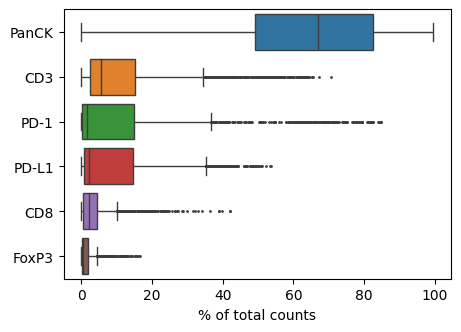

OMP: Info #276: omp_set_nested routine deprecated, please use omp_set_max_active_levels instead.


In [13]:
sc.pl.highest_expr_genes(sc_adata_p1, n_top=10, )

sc.pp.neighbors(sc_adata_p1)

In [58]:
sc.tl.leiden(sc_adata_p1, resolution = 0.1, key_added = "leiden_0.4")

In [59]:
sc.tl.umap(sc_adata_p1,min_dist=0.8)

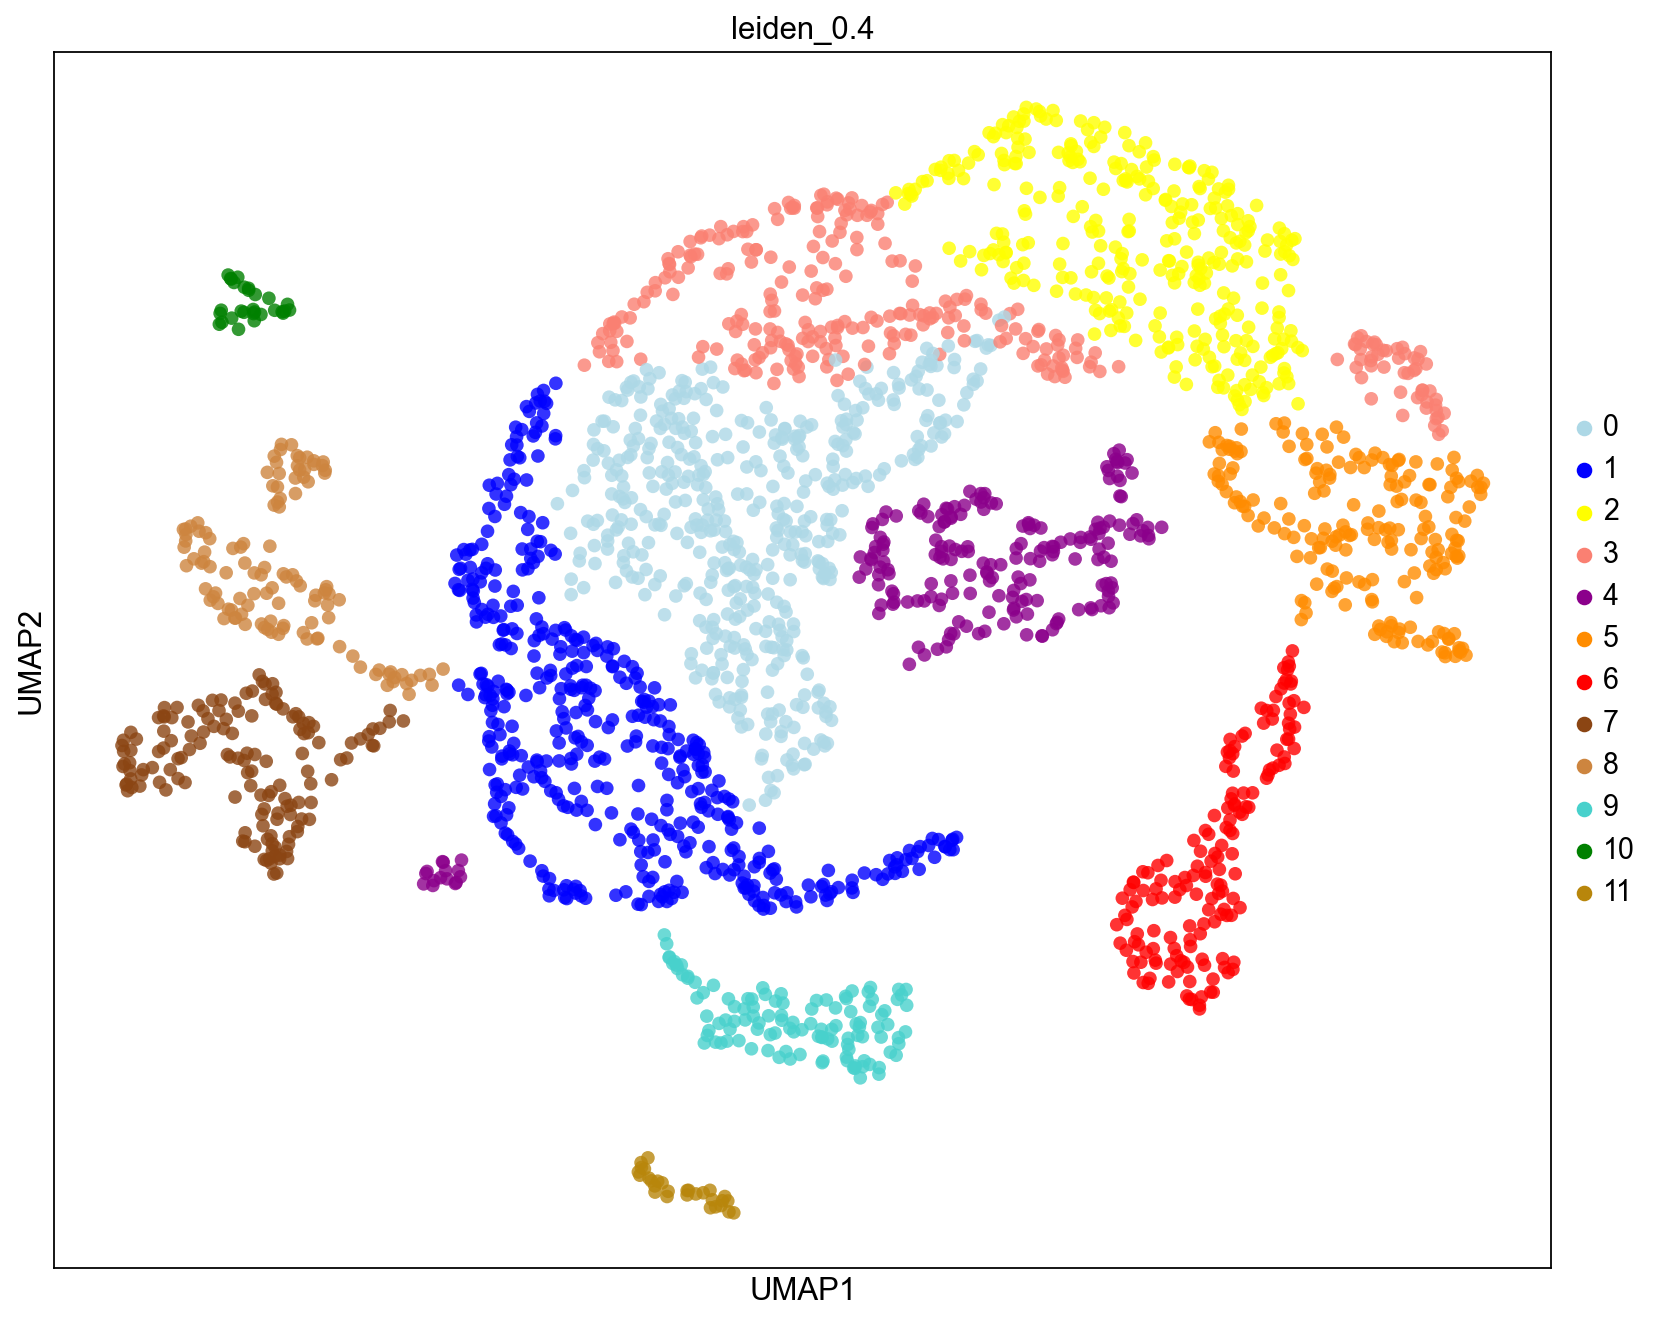

In [71]:
sc.pl.umap(sc_adata_p1, color=['leiden_0.4'],s=150,alpha=0.8,palette=[ "lightblue","blue","yellow","salmon","darkmagenta","darkorange","red","saddlebrown","peru","mediumturquoise","green","darkgoldenrod"])#, 'leiden_0.6', 'leiden_1.0','leiden_1.4'])

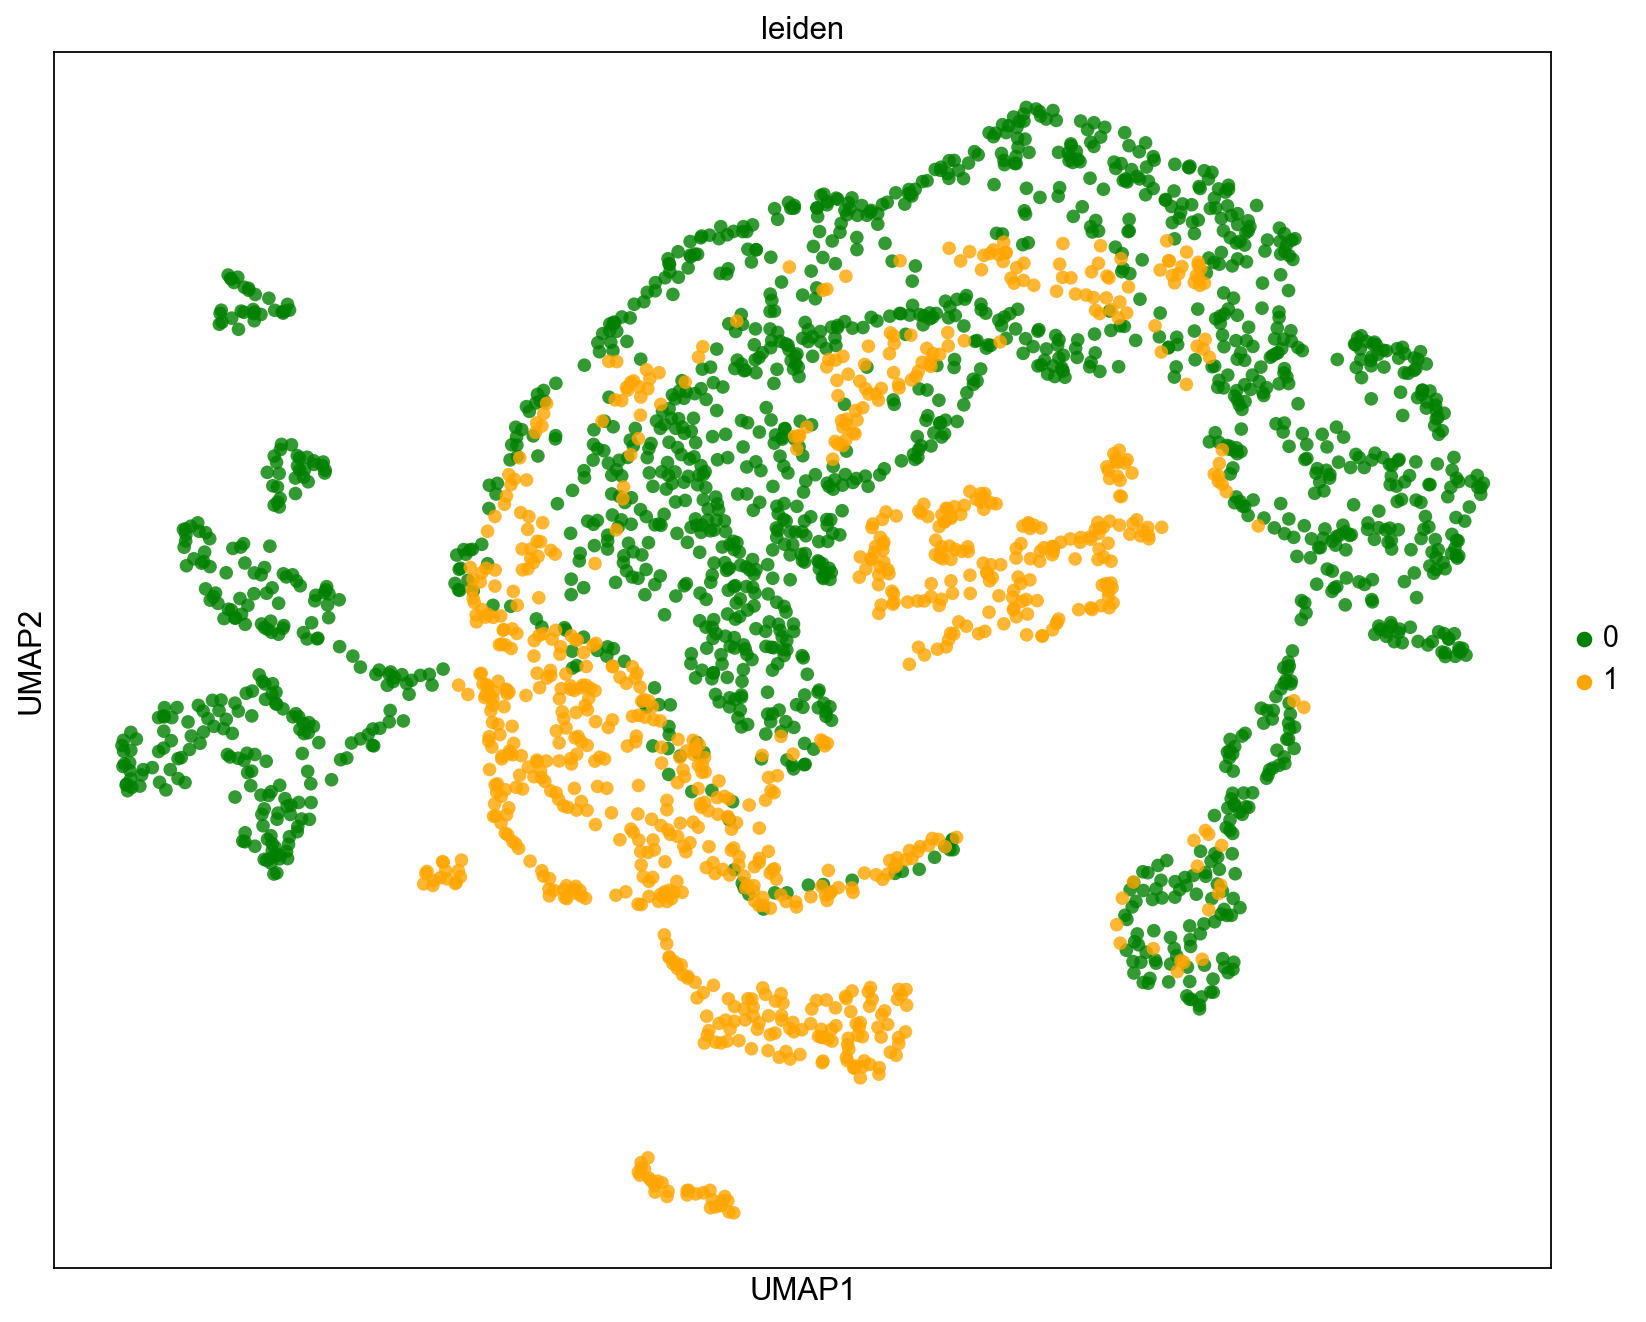

In [46]:
sc.set_figure_params(figsize=(12,10))
sc_adata_p1.obs["leiden"] = pd.Categorical(resp_cat)
sc.pl.umap(sc_adata_p1, color=['leiden'], palette=[ "green","orange"],s=150,alpha=0.8)#,cmap='viridis', vmin=-2, vmax=5)


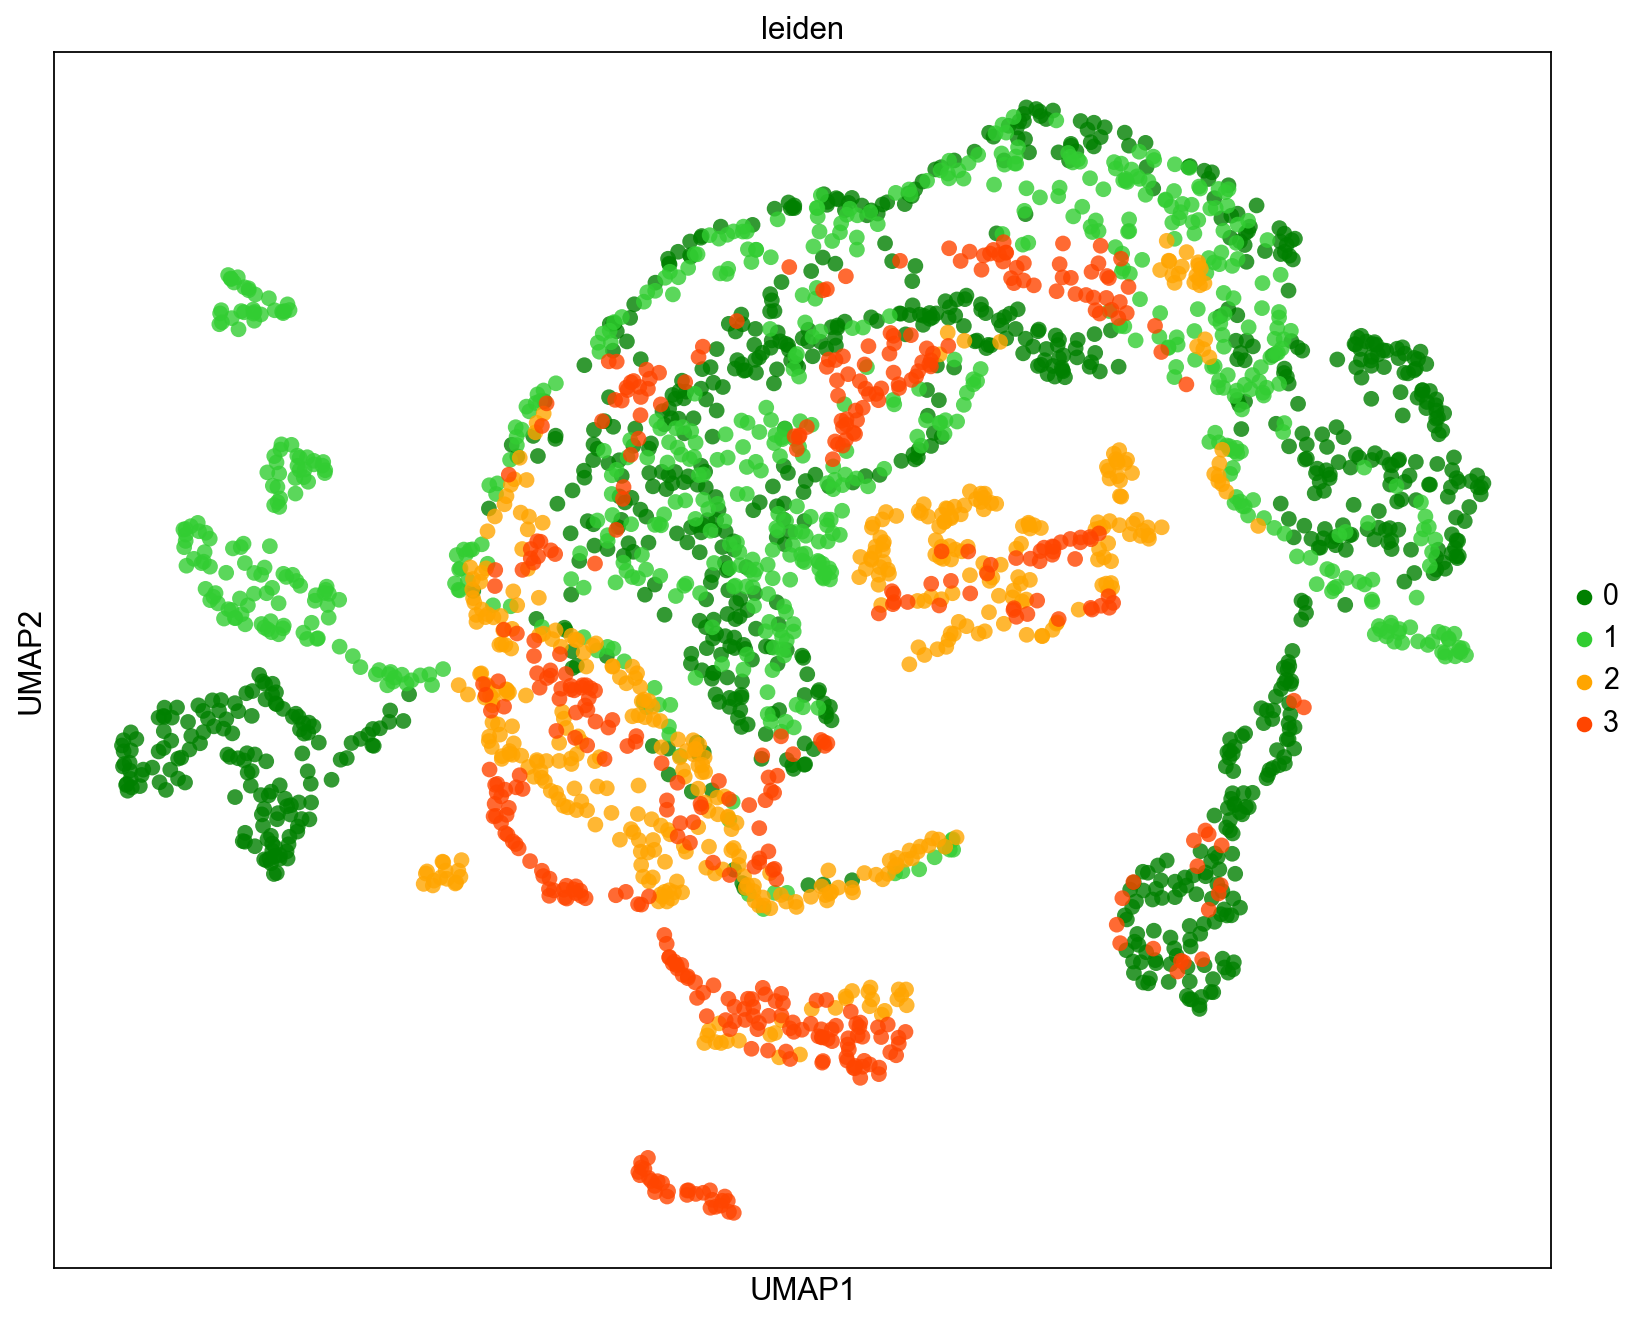

In [51]:
sc.set_figure_params(figsize=(12,10))

sc_adata_p1.obs["leiden"] = pd.Categorical(time_cat)
sc.pl.umap(sc_adata_p1, color=['leiden'], palette=[ "green","limegreen","orange","orangered",],s=200,alpha=0.8)#,cmap='viridis', vmin=-2, vmax=5)

In [68]:
sc.tl.dendrogram(sc_adata_p1, groupby='leiden_0.4')

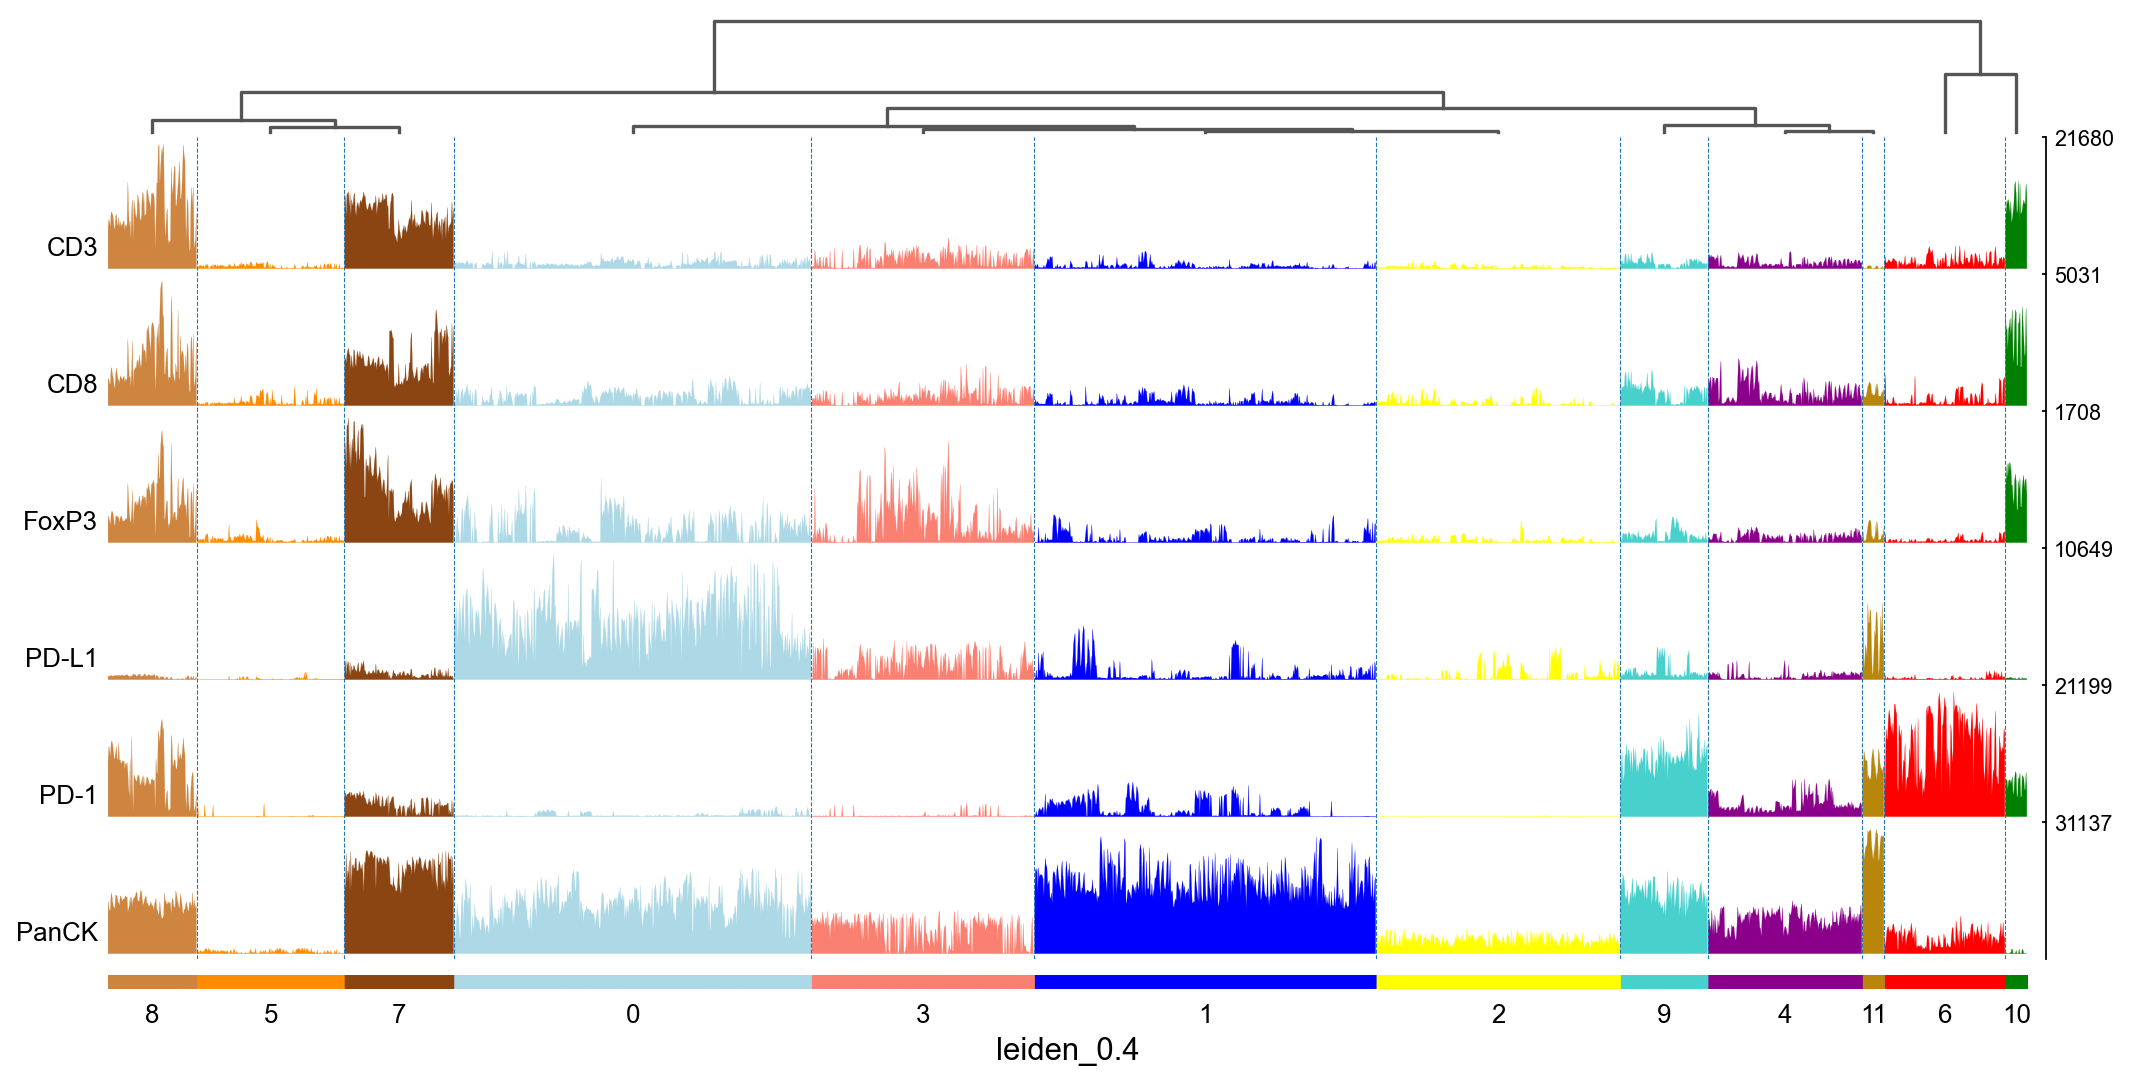

In [75]:
ax = sc.pl.tracksplot(sc_adata_p1, sc_adata_p1.var_names,groupby='leiden_0.4', dendrogram=True, figsize=(16,8),dpi=550)

In [25]:
cluster_leiden = np.array(sc_adata_p1.obs['leiden_0.4'],dtype='int')

#### resp heterogenity

In [26]:
unique_ts, counts_ts = np.unique(time_cat, return_counts=True)
print(unique_ts.shape[0])

unique_12, counts_12 = np.unique(cluster_leiden, return_counts=True)
print(unique_12.shape[0])
print(counts_12)


4
12
[470 449 321 293 203 194 159 144 117 115  29  29]


In [27]:

#label_categ=['PD on' = 3,'PD pre = 2','SD on = 1', 'SD pre'= 0]

pdo_list_n = []
pdpre_list_n = []
sdo_list_n = []
sdpre_list_n = []

pd_list_n = []
sd_list_n = []

tot_cells = time_cat.shape[0]

pd_list_n = []
sd_list_n = []

# get the rows for sd, pd, pr
unique_ts, counts_ts = np.unique(time_cat, return_counts=True)
print(unique_ts)
pdo = np.array(np.where(time_cat==unique_ts[3])).flatten()
pdpre = np.array(np.where(time_cat==unique_ts[2])).flatten()
sdo = np.array(np.where(time_cat==unique_ts[1])).flatten()
sdpre = np.array(np.where(time_cat==unique_ts[0])).flatten()



for l in range(unique_12.shape[0]): #at the cluster level
    f_rows = np.array(np.where(np.array(cluster_leiden==l))).flatten()
    pdo_f = np.intersect1d(pdo,f_rows)
    pdo_list_n.append(pdo_f.shape[0]*100/pdo.shape[0])  ##check normalization
    #pd_list_n.append(pdo_f.shape[0]*100/pdo.shape[0])  ##check normalization
    
    pdpre_f = np.intersect1d(pdpre,f_rows)
    pdpre_list_n.append(pdpre_f.shape[0]*100/pdpre.shape[0])
    pd_list_n.append(np.mean([pdpre_f.shape[0]*100/pdpre.shape[0],pdo_f.shape[0]*100/pdo.shape[0]]))
    
    sdo_f = np.intersect1d(sdo,f_rows)
    sdo_list_n.append(sdo_f.shape[0]*100/sdo.shape[0])
    #sd_list_n.append(sdo_f.shape[0]*100/sdo.shape[0])  ##check normalization
    
    sdpre_f = np.intersect1d(sdpre,f_rows)
    sdpre_list_n.append(sdpre_f.shape[0]*100/sdpre.shape[0])
    sd_list_n.append(np.mean([sdpre_f.shape[0]*100/sdpre.shape[0],sdo_f.shape[0]*100/sdo.shape[0]]))
    


[0 1 2 3]


In [29]:

#from traceplot

cell_classes = [
'PD-L1+PanCK+',
'PanCK+',
'CD8+PD-L1+PanCK+',
'FoxP3+',
'FoxP3+PD-1+PanCK+',    
'FoxP3+CD8+PanCK+',
'PD-1',
'CD3+CD8+FoxP3+PD-L1+PanCK+',
'CD3+CD8+FoxP3+PD-1+PanCK+',
'CD8+FoxP3+PD-1+PanCK+',
'CD3+CD8+FoXP3+PD-1',
'CD8+FoxP3+PD-1+PD-L1+PanCK+']



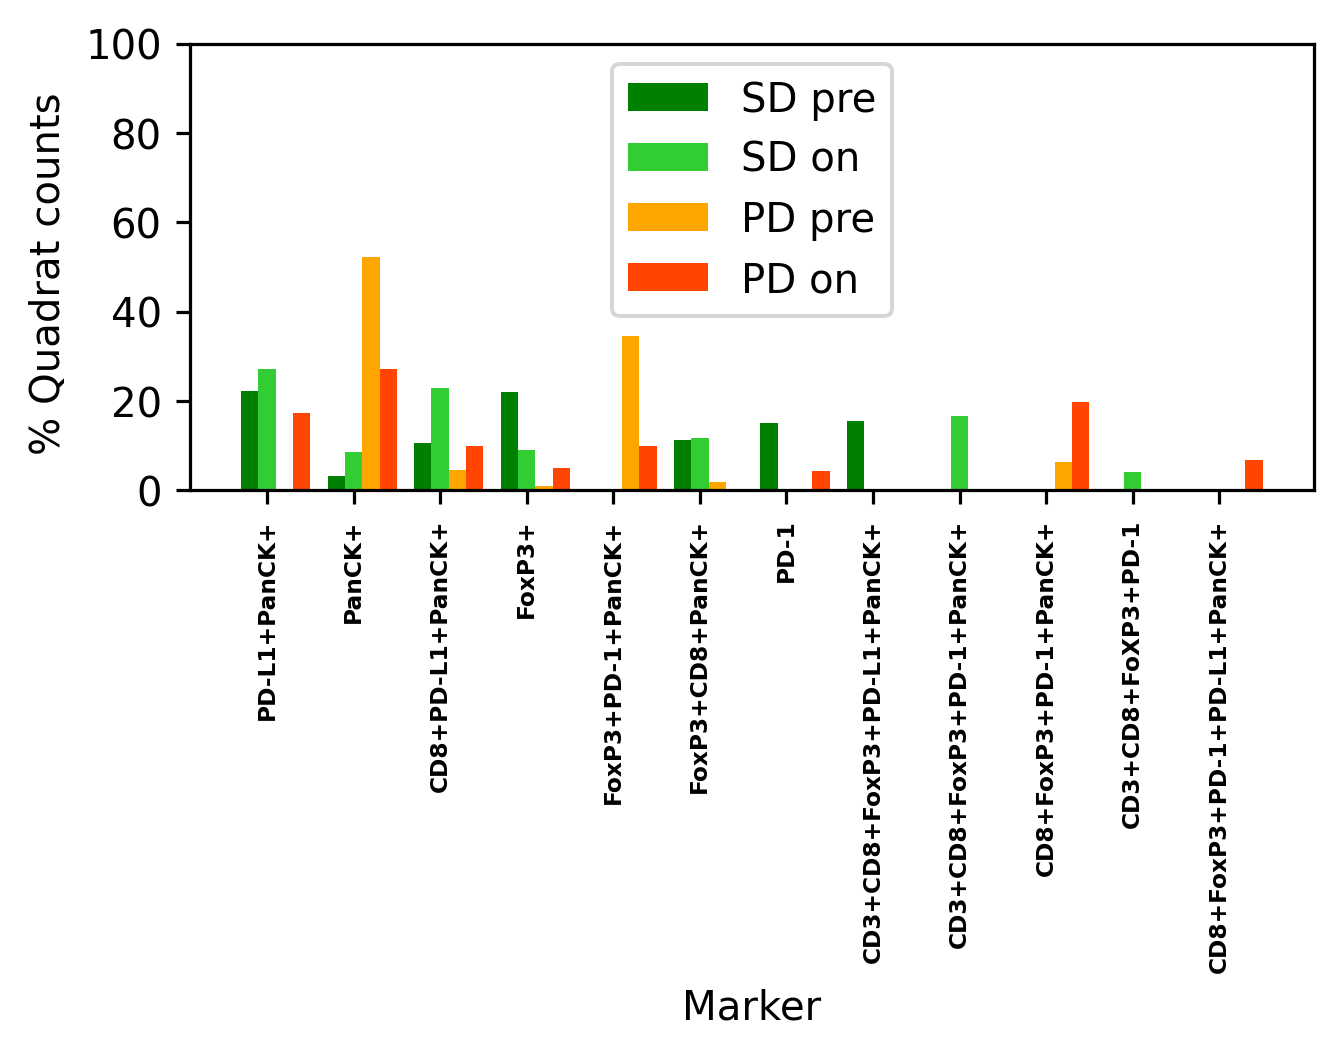

In [39]:
## 

plt.figure(figsize=(5,2), dpi=290)
# create data 
x = np.arange(12) 
y4 = pdo_list_n
y3 = pdpre_list_n
y2 = sdo_list_n
y1 = sdpre_list_n
width = 0.2
  
# plot data in grouped manner of bar type 
plt.bar(x-0.2, y1, width, color='green') 
plt.bar(x, y2, width, color='limegreen') 
plt.bar(x+0.2, y3, width, color='orange') 
plt.bar(x+0.4, y4, width, color='orangered') # shades 
plt.xticks(x, cell_classes,rotation=90,fontsize='xx-small',fontweight='bold')  
plt.xlabel("Marker") 
plt.ylabel("% Quadrat counts ")#
plt.legend(["SD pre","SD on", "PD pre", "PD on"], loc=9) 
plt.ylim(0,100)
plt.show() 

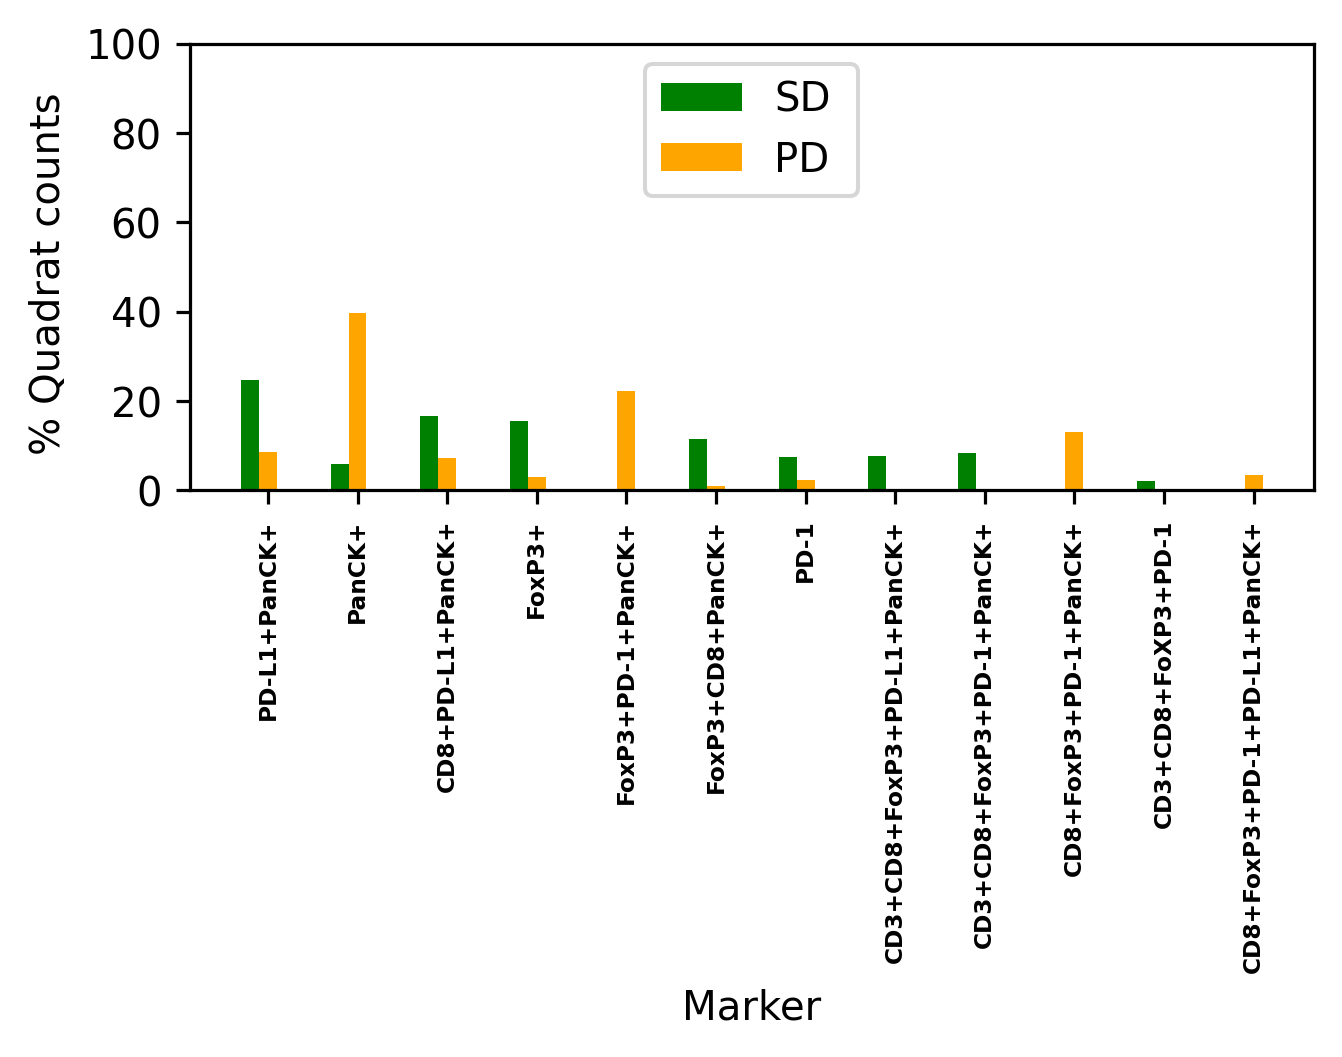

In [37]:
##

plt.figure(figsize=(5,2), dpi=290)
# create data 
x = np.arange(12) 
y2 = pd_list_n
y1 = sd_list_n
width = 0.2
  
# plot data in grouped manner of bar type 
plt.bar(x-0.2, y1, width, color='green') 
plt.bar(x, y2, width, color='orange') 
#plt.bar(x+0.2, y3, width, color='orange') 
#plt.bar(x+0.4, y4, width, color='orangered') # shades 
plt.xticks(x, cell_classes,rotation=90,fontsize='xx-small', fontweight='bold') 
plt.xlabel("Marker") 
plt.ylabel("% Quadrat counts ")
plt.legend(["SD", "PD "], loc=9) 
plt.ylim(0,100)
plt.show() 